In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import ast
import os

In [2]:
df = pd.read_csv('./data/df_alter.csv')

In [3]:
# Load the aggregate edge list
edges = pd.read_csv("./edge_counts_edgelist.csv")

# Create the graph
G_all = nx.Graph()
for _, row in edges.iterrows():
    G_all.add_edge(row['source'], row['target'], weight=row['weight'])

In [4]:
# Degree centrality (how many unique connections)
degree = dict(G_all.degree())

# Weighted degree (sum of edge weights)
strength = dict(G_all.degree(weight='weight'))

# Betweenness centrality (bridging potential)
betweenness = nx.betweenness_centrality(G_all, weight='weight', normalized=True)

In [5]:
out_counts = (
    df[df['in_gcc'] == False]
    .groupby('name')
    .size()
    .rename('out_of_gcc_count')
)

In [6]:
agg_df = pd.DataFrame({
    'name': list(G_all.nodes()),
    'degree': [degree.get(n, 0) for n in G_all.nodes()],
    'strength': [strength.get(n, 0) for n in G_all.nodes()],
    'betweenness': [betweenness.get(n, 0) for n in G_all.nodes()]
}).merge(out_counts, on='name', how='left').fillna({'out_of_gcc_count': 0})

In [7]:
latent_bridges = agg_df[
    (agg_df['out_of_gcc_count'] >= 2) &
    (agg_df['betweenness'] >= agg_df['betweenness'].quantile(0.75))
]

In [8]:
agg_df[['name', 'betweenness']].sort_values('betweenness', ascending=False)

,name,betweenness
22,inequality,0.095065
6,empirical data,0.087162
3,context,0.085047
28,individual,0.064271
7,ethics,0.063606
9,macro-micro,0.062200
4,culture,0.059272
2,change,0.050009
17,truth,0.046240
16,technology,0.045444


In [9]:
from scipy.stats import spearmanr
rho, p = spearmanr(agg_df['out_of_gcc_count'], agg_df['betweenness'])
print(f"Spearman correlation = {rho:.3f} (p = {p:.4f})")

Spearman correlation = 0.035 (p = 0.8434)


In [10]:
out_counts

name
AI                 3
analysis           1
art                1
community          2
context            1
culture            1
design             2
development        1
empirical data     1
ethics             2
history            1
identity           2
justice            1
knowledge          2
music              1
optimisation       2
perspective        1
policy             2
power              1
privacy            1
progress           1
social networks    2
social norms       1
structure          2
technology         1
theory             1
truth              1
user experience    1
Name: out_of_gcc_count, dtype: int64

In [11]:
nx.density(G_all)

0.2727272727272727

,group,density_mean,density_sem,modularity_mean,modularity_sem
0,with empirical data,0.287172,0.046428,0.355793,0.044620
1,without empirical data,0.200989,0.053170,0.222974,0.061739


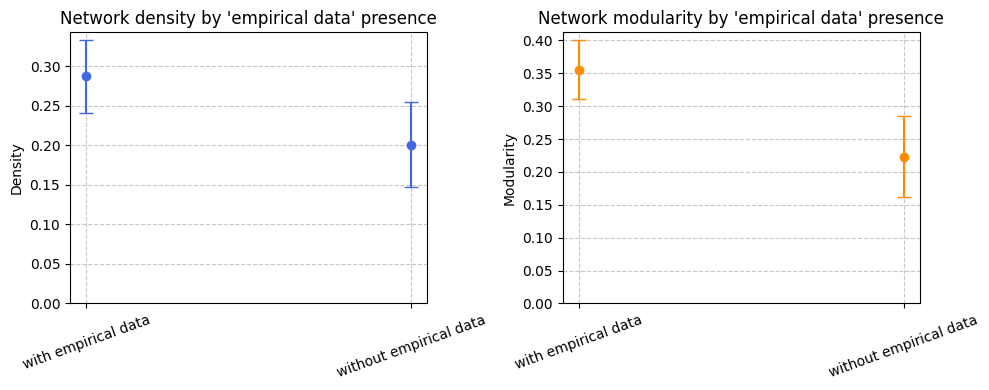

Top betweenness node in networks WITHOUT 'empirical data':


,participant_id,top_betweenness_node,top_betweenness_value
0,cmh1trlci0002sa278d3vv3ip,community,0.156944
3,cmh1uot9n000osa27eayyicd9,AI,0.000000
8,cmh20nti10021sa2781v0n7gr,individual,0.636364
9,cmh20p3iy0027sa27jqf9dcog,knowledge,0.319697
10,cmh20pce1002asa27bbo97iav,analysis,0.666667
13,cmh2780t1002osa278qk4yn4v,AI,0.513889
16,cmh4n1pe9003gsa27d06mabf0,AI,0.000000


Betweenness of 'empirical data' in networks that HAVE it:


,participant_id,empirical_data_betweenness,top_betweenness_node,top_betweenness_value
1,cmh1u7a3d000bsa27gwe0vmf6,0.106481,AI,0.476852
2,cmh1ulurw000lsa2750fqbpip,0.268519,ethics,0.500000
4,cmh1w9kqc0011sa27sx6ud8sm,0.119394,empirical data,0.119394
5,cmh200ziw001hsa27kc2dl64f,0.140606,community,0.182727
6,cmh205bqc001qsa273cbrl5cg,0.000000,technology,0.088889
7,cmh20bfbo001vsa27rn1wly2f,0.045455,context,0.418182
11,cmh20rd26002dsa27jo124g0a,0.000000,ethics,0.472222
12,cmh21d16h002ksa27lkj9ip6g,0.018182,empirical data,0.018182
14,cmh291q1v002vsa27a241pgye,0.000000,ethics,0.200000
15,cmh2gexi60035sa27kedegg6s,0.000000,social norms,0.566667


In [15]:
# --- Focused comparison: density & modularity vs presence of "inequality" ---
import ast, numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import community as nx_comm

UUID_COL = "networkCanvasUUID"
NAME_COL = "name"
CONNECTED_COL = "connected_concepts"
PART_COL = "participant_id"
FOCUS_CONCEPT = "empirical data"

def parse_connected(cell):
    if pd.isna(cell):
        return []
    if isinstance(cell, (list, tuple)):
        return [str(x) for x in cell]
    s = str(cell).strip()
    if s == "":
        return []
    try:
        val = ast.literal_eval(s)
        if isinstance(val, (list, tuple)):
            return [str(x) for x in val]
    except Exception:
        pass
    s2 = s.strip("[]() ")
    if not s2:
        return []
    return [p.strip().strip("'\"") for p in s2.split(",") if p.strip()]

def build_participant_graph(sub):
    id_to_name = {str(r[UUID_COL]): r[NAME_COL] for _, r in sub.iterrows() if pd.notna(r.get(UUID_COL))}
    G = nx.Graph()
    for _, r in sub.iterrows():
        name = r[NAME_COL]
        if pd.notna(name):
            G.add_node(name)
    for _, r in sub.iterrows():
        src_uuid = str(r[UUID_COL])
        src_name = id_to_name.get(src_uuid)
        if src_name is None:
            continue
        for nb in parse_connected(r.get(CONNECTED_COL, "")):
            nb = str(nb)
            tgt_name = id_to_name.get(nb)
            if tgt_name and src_name != tgt_name:
                G.add_edge(src_name, tgt_name)
    return G

def compute_modularity(G):
    if G.number_of_edges() == 0 or G.number_of_nodes() < 3:
        return np.nan
    try:
        comms = list(nx_comm.greedy_modularity_communities(G))
        return nx_comm.modularity(G, comms)
    except Exception:
        return np.nan

# --- Compute metrics per participant ---
rows = []
for pid, sub in df.groupby(PART_COL):
    G = build_participant_graph(sub)
    betweenness = nx.betweenness_centrality(G, normalized=True) if G.number_of_edges() > 0 else {}
    top_node = max(betweenness, key=betweenness.get) if betweenness else None
    top_value = betweenness.get(top_node, np.nan) if betweenness else np.nan

    rows.append({
        "participant_id": pid,
        "has_inequality": FOCUS_CONCEPT in G.nodes,
        "density": nx.density(G),
        "modularity": compute_modularity(G),
        "top_betweenness_node": top_node,
        "top_betweenness_value": top_value,
        "empirical_data_betweenness": betweenness.get(FOCUS_CONCEPT, np.nan)
    })

metrics = pd.DataFrame(rows)

# --- Split groups ---
with_ineq = metrics[metrics["has_inequality"]]
without_ineq = metrics[~metrics["has_inequality"]]

# --- Compute group means & error bars ---
summary = pd.DataFrame({
    "group": ["with empirical data", "without empirical data"],
    "density_mean": [with_ineq["density"].mean(), without_ineq["density"].mean()],
    "density_sem": [with_ineq["density"].std(ddof=1)/np.sqrt(len(with_ineq)), without_ineq["density"].std(ddof=1)/np.sqrt(len(without_ineq))],
    "modularity_mean": [with_ineq["modularity"].mean(), without_ineq["modularity"].mean()],
    "modularity_sem": [with_ineq["modularity"].std(ddof=1)/np.sqrt(len(with_ineq)), without_ineq["modularity"].std(ddof=1)/np.sqrt(len(without_ineq))]
})

display(summary)

# --- Plot scatter-style chart with error bars ---
fig, ax = plt.subplots(1,2, figsize=(10,4))

# Density
ax[0].errorbar(x=[0,1],
               y=summary["density_mean"],
               yerr=summary["density_sem"],
               fmt='o', capsize=5, color='royalblue')
ax[0].set_xticks([0,1])
ax[0].set_xticklabels(summary["group"], rotation=20)
ax[0].set_ylabel("Density")
ax[0].set_title("Network density by 'empirical data' presence")
ax[0].set_ylim(bottom=0)
ax[0].grid(True, linestyle='--', alpha=0.7)  # <-- add grid lines

# Modularity
ax[1].errorbar(x=[0,1],
               y=summary["modularity_mean"],
               yerr=summary["modularity_sem"],
               fmt='o', capsize=5, color='darkorange')
ax[1].set_xticks([0,1])
ax[1].set_xticklabels(summary["group"], rotation=20)
ax[1].set_ylabel("Modularity")
ax[1].set_title("Network modularity by 'empirical data' presence")
ax[1].set_ylim(bottom=0)
ax[1].grid(True, linestyle='--', alpha=0.7)  # <-- add grid lines


plt.tight_layout()
plt.show()

# --- Highest-betweenness nodes in networks without inequality ---
print("Top betweenness node in networks WITHOUT 'empirical data':")
display(without_ineq[["participant_id", "top_betweenness_node", "top_betweenness_value"]])

# --- Betweenness of 'inequality' in networks that include it ---
print("Betweenness of 'empirical data' in networks that HAVE it:")
display(with_ineq[["participant_id", "empirical_data_betweenness", "top_betweenness_node", "top_betweenness_value"]])